In [7]:
# 1) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

# 2) Load CSV
path = Path('car_prices.csv')  # ensure the file is in your working directory
df = pd.read_csv(path)

# 3) Normalize column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Inspect
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


In [10]:
# Identify key columns
price_col = 'sellingprice' if 'sellingprice' in df.columns else ('price' if 'price' in df.columns else None)
odo_col   = 'odometer' if 'odometer' in df.columns else ('kilometres' if 'kilometres' in df.columns else None)

if price_col is None:
    raise ValueError("Couldn't find target price column. Expected 'sellingprice' or 'price'.")

# Coerce price and odometer to numeric
for c in [price_col, odo_col]:
    if c in df.columns and df[c].dtype == 'O':
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Convert saledate to datetime if present
if 'saledate' in df.columns:
    # Parse to timezone-aware UTC datetimes
    df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)

# If you don't need timezone-awareness, convert to local-naive timestamps
df['saledate'] = df['saledate'].dt.tz_convert('UTC').dt.tz_localize(None)

# Remove rows with missing target
df = df.dropna(subset=[price_col]).copy()

print("Rows after dropping missing target:", len(df))

/tmp/ipykernel_8028/433280091.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)


Rows after dropping missing target: 558825


In [11]:
def iqr_trim(s: pd.Series, k: float = 1.5):
    """Return lower & upper bounds for IQR trimming."""
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

rows_before = len(df)

# IQR on price
low, high = iqr_trim(df[price_col].dropna())
df = df[(df[price_col] >= low) & (df[price_col] <= high)].copy()

# IQR on odometer (if exists)
if odo_col in df.columns and df[odo_col].notna().sum() > 0:
    low, high = iqr_trim(df[odo_col].dropna())
    df = df[(df[odo_col] >= low) & (df[odo_col] <= high)].copy()

rows_after = len(df)
print(f"Outliers removed: {rows_before - rows_after} (remaining rows: {rows_after})")

Outliers removed: 26150 (remaining rows: 532675)


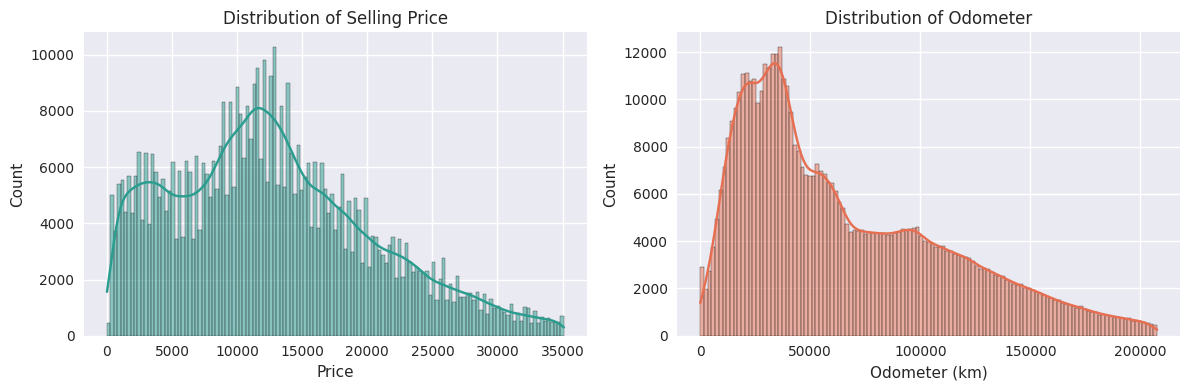

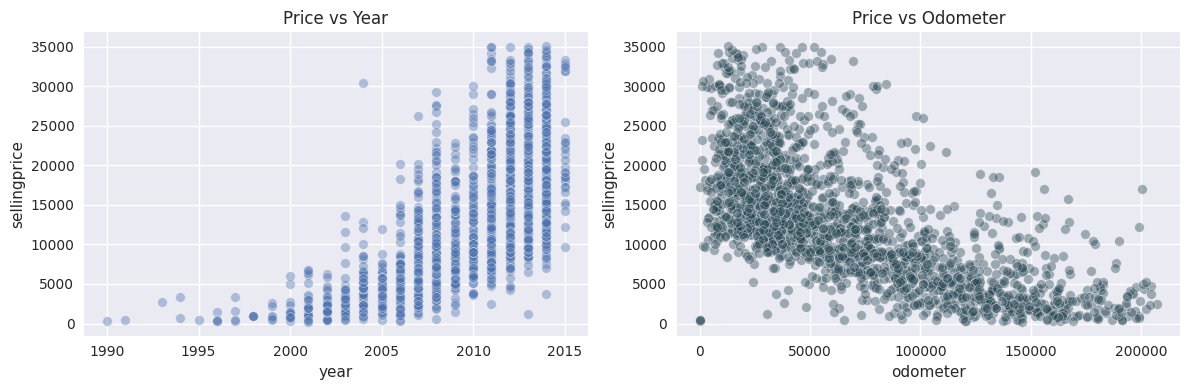

make
Ford         90281
Chevrolet    57107
Nissan       53359
Toyota       38264
Dodge        30108
Honda        26092
Hyundai      21631
Kia          17964
BMW          17302
Chrysler     17113
Name: count, dtype: int64


In [12]:
# Distributions
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df[price_col], kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of Selling Price'); axes[0].set_xlabel('Price')

if odo_col in df.columns:
    sns.histplot(df[odo_col], kde=True, ax=axes[1], color='#e76f51')
    axes[1].set_title('Distribution of Odometer'); axes[1].set_xlabel('Odometer (km)')
plt.tight_layout(); plt.show()

# Price vs. year / odometer
fig, axes = plt.subplots(1, 2, figsize=(12,4))
if 'year' in df.columns:
    sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42), x='year', y=price_col, alpha=0.4, ax=axes[0])
    axes[0].set_title('Price vs Year')
if odo_col in df.columns:
    sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42), x=odo_col, y=price_col, alpha=0.4, ax=axes[1], color='#264653')
    axes[1].set_title('Price vs Odometer')
plt.tight_layout(); plt.show()

# Top categories (optional): make/model counts
if 'make' in df.columns:
    print(df['make'].value_counts().head(10))

In [14]:
# Columns to drop from features
to_drop = [price_col, 'vin', 'seller', 'saledate']
X = df.drop(columns=[c for c in to_drop if c in df.columns]).copy()
y = df[price_col].copy()

# Identify column types
num_cols = X.select_dtypes(include=['number']).columns.tolist()
# Future-proof, explicit dtype selection
cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns (encoded):", cat_cols)

# Preprocess blocks
numeric_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_tf, num_cols),
        ('cat', categorical_tf, cat_cols)
    ]
)

Numeric columns: ['year', 'condition', 'odometer', 'mmr']
Categorical columns (encoded): ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_model = Pipeline(steps=[
    ('prep', preprocess),
    ('model', LinearRegression())
])

rf_model = Pipeline(steps=[
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

lin_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)